In [1]:
import json
import pandas as pd

In [10]:
json_file = "Sarcasm_Headlines_Dataset.json"

df = pd.read_json(json_file, lines=True)
df.head()

,article_link,headline,is_sarcastic
0,https://www.huffingtonpost.com/entry/versace-b...,former versace store clerk sues over secret 'b...,0
1,https://www.huffingtonpost.com/entry/roseanne-...,the 'roseanne' revival catches up to our thorn...,0
2,https://local.theonion.com/mom-starting-to-fea...,mom starting to fear son's web series closest ...,1
3,https://politics.theonion.com/boehner-just-wan...,"boehner just wants wife to listen, not come up...",1
4,https://www.huffingtonpost.com/entry/jk-rowlin...,j.k. rowling wishes snape happy birthday in th...,0


In [11]:
df.to_csv('sarcasm.csv', index=False)

In [12]:
data = pd.read_csv('sarcasm.csv')
data.head()

,article_link,headline,is_sarcastic
0,https://www.huffingtonpost.com/entry/versace-b...,former versace store clerk sues over secret 'b...,0
1,https://www.huffingtonpost.com/entry/roseanne-...,the 'roseanne' revival catches up to our thorn...,0
2,https://local.theonion.com/mom-starting-to-fea...,mom starting to fear son's web series closest ...,1
3,https://politics.theonion.com/boehner-just-wan...,"boehner just wants wife to listen, not come up...",1
4,https://www.huffingtonpost.com/entry/jk-rowlin...,j.k. rowling wishes snape happy birthday in th...,0


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26709 entries, 0 to 26708
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   article_link  26709 non-null  object
 1   headline      26709 non-null  object
 2   is_sarcastic  26709 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 626.1+ KB


In [14]:
data.describe()

,is_sarcastic
count,26709.000000
mean,0.438953
std,0.496269
min,0.000000
25%,0.000000
50%,0.000000
75%,1.000000
max,1.000000


In [15]:
data['is_sarcastic'].value_counts()

is_sarcastic
0    14985
1    11724
Name: count, dtype: int64

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(data['headline'], data['is_sarcastic'], test_size=0.2)

In [18]:
len(X_train), len(X_test), len(y_train), len(y_test)

(21367, 5342, 21367, 5342)

In [21]:
X_train.head()

10876    james comey's book pre-sold almost 200,000 cop...
22194    should we give cops 'benefit of the doubt' whe...
17154    what actually happens when gay guys see other ...
11894    report: 79% of minority suspects receive miran...
7369     dancing 7-year-old looks to expand fan base fr...
Name: headline, dtype: object

In [22]:
from tensorflow.keras.layers import TextVectorization


In [25]:
text_vectorizer = TextVectorization(max_tokens=10000,
                                    standardize='lower_and_strip_punctuation',
                                    split='whitespace',
                                    ngrams=None,
                                    output_mode='int',
                                    output_sequence_length=None,
                                    pad_to_max_tokens=True)

In [26]:
max_vocab_size = 10000
max_length = 15

text_vectorizer = TextVectorization(max_tokens=max_vocab_size,
                                    output_mode='int',
                                    output_sequence_length=max_length)

In [27]:
text_vectorizer.adapt(X_train)

In [29]:
words_in_vocab = text_vectorizer.get_vocabulary()
top_5_words = words_in_vocab[:5]
top_5_words

['', '[UNK]', 'to', 'of', 'the']

In [30]:
import tensorflow as tf

embedding = tf.keras.layers.Embedding(input_dim=max_vocab_size,
                                       output_dim=128,
                                       mask_zero=True,
                                      embeddings_initializer='uniform',
                                      input_length=max_length)
embedding


In [31]:
random_sentence = random.choice(X_train)
print(f"Original text: {random_sentence}")
print(f"Vectorized text: {text_vectorizer([random_sentence])}")

Original text: stunned family watches as grandmother wolfs down sandwich in 33 minutes
Vectorized text: [[5093   86 3533   28 1390 7144   84 1309    5 4970  352    0    0    0
     0]]


In [32]:
#baseline model

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

model_0 = Pipeline([
    ("tfidf", TfidfVectorizer()), # convert text to numbers
    ("clf", MultinomialNB()) # model the text
])

model_0.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer()), ('clf', MultinomialNB())])

In [34]:
model_0_score = model_0.score(X_test, y_test)
print(f"Model_0 accuracy: {model_0_score*100:.2f}%")

Model_0 accuracy: 82.18%


In [36]:
model_0_pred_probs = model_0.predict(X_test)
model_0_pred_probs[:10]

array([1, 0, 0, 0, 1, 0, 0, 0, 1, 0])

In [40]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def calulate_results(y_true, y_pred):
  model_accuracy = accuracy_score(y_true, y_pred) * 100
  model_precision, model_recall, model_f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")
  model_results = {"accuracy": model_accuracy,
                   "precision": model_precision,
                   "recall": model_recall,
                   "f1": model_f1}
  return model_results

In [41]:
model_0_results = calulate_results(y_true=y_test, y_pred=model_0_pred_probs)
model_0_results

{'accuracy': 82.17895919131412,
 'precision': 0.8339846081922483,
 'recall': 0.8217895919131412,
 'f1': 0.816751613283982}

In [42]:
#LSTM

In [43]:
inputs = tf.keras.layers.Input(shape=(1,), dtype=tf.string)
x = text_vectorizer(inputs)
x = embedding(x)
x = tf.keras.layers.LSTM(64, return_sequences=True)(x)
x = tf.keras.layers.LSTM(64)(x)
x = tf.keras.layers.Dense(64, activation='relu')(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model_1 = tf.keras.Model(inputs, outputs, name="model_1_LSTM")

model_1.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

model_1.summary()

Model: "model_1_LSTM"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 1)]               0         
                                                                 
 text_vectorization_1 (Text  (None, 15)                0         
 Vectorization)                                                  
                                                                 
 embedding (Embedding)       (None, 15, 128)           1280000   
                                                                 
 lstm (LSTM)                 (None, 15, 64)            49408     
                                                                 
 lstm_1 (LSTM)               (None, 64)                33024     
                                                                 
 dense (Dense)               (None, 64)                4160      
                                                      

In [44]:
model_1.fit(X_train,
            y_train,
            epochs=5,
            validation_data=(X_test, y_test),
            batch_size=32)

Epoch 1/5
668/668 [==============================] - 29s 28ms/step - loss: 0.3903 - accuracy: 0.8226 - val_loss: 0.3472 - val_accuracy: 0.8516
Epoch 2/5
668/668 [==============================] - 11s 17ms/step - loss: 0.2165 - accuracy: 0.9151 - val_loss: 0.3510 - val_accuracy: 0.8519
Epoch 3/5
668/668 [==============================] - 11s 16ms/step - loss: 0.1228 - accuracy: 0.9542 - val_loss: 0.5125 - val_accuracy: 0.8456
Epoch 4/5
668/668 [==============================] - 11s 16ms/step - loss: 0.0663 - accuracy: 0.9768 - val_loss: 0.5845 - val_accuracy: 0.8356
Epoch 5/5
668/668 [==============================] - 9s 14ms/step - loss: 0.0371 - accuracy: 0.9868 - val_loss: 0.6649 - val_accuracy: 0.8381


In [45]:
model_1_pred_probs = model_1.predict(X_test)
model_1_pred_probs

167/167 [==============================] - 4s 7ms/step


array([[0.98997974],
       [0.9996513 ],
       [0.2571876 ],
       ...,
       [0.00879555],
       [0.9925736 ],
       [0.2720146 ]], dtype=float32)

In [46]:
model_1_preds = tf.squeeze(tf.round(model_1_pred_probs))

model_1_results = calulate_results(y_true=y_test, y_pred=model_1_preds)
model_1_results

{'accuracy': 83.80756271059528,
 'precision': 0.8379288389769562,
 'recall': 0.8380756271059528,
 'f1': 0.8379891263864077}

In [47]:
#gated recurrent unit

In [48]:
#Bidirectional RNN
inputs = tf.keras.layers.Input(shape=(1,), dtype=tf.string)
x = text_vectorizer(inputs)
x = embedding(x)
x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(62, return_sequences=True))(x)
x = tf.keras.layers.Bidirectional(tf.keras.layers.GRU(62))(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model_2 = tf.keras.Model(inputs, outputs)
model_2.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 1)]               0         
                                                                 
 text_vectorization_1 (Text  (None, 15)                0         
 Vectorization)                                                  
                                                                 
 embedding (Embedding)       (None, 15, 128)           1280000   
                                                                 
 bidirectional (Bidirection  (None, 15, 124)           94736     
 al)                                                             
                                                                 
 bidirectional_1 (Bidirecti  (None, 124)               69936     
 onal)                                                           
                                                             

In [49]:
model_2.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

model_2_history = model_2.fit(X_train,
                              y_train,
                              epochs=5,
                              validation_data=(X_test, y_test),
                              batch_size=32)

Epoch 1/5
668/668 [==============================] - 43s 40ms/step - loss: 0.0846 - accuracy: 0.9678 - val_loss: 0.6176 - val_accuracy: 0.8338
Epoch 2/5
668/668 [==============================] - 16s 24ms/step - loss: 0.0233 - accuracy: 0.9922 - val_loss: 0.8082 - val_accuracy: 0.8336
Epoch 3/5
668/668 [==============================] - 16s 24ms/step - loss: 0.0128 - accuracy: 0.9956 - val_loss: 0.9193 - val_accuracy: 0.8302
Epoch 4/5
668/668 [==============================] - 15s 23ms/step - loss: 0.0128 - accuracy: 0.9955 - val_loss: 0.9460 - val_accuracy: 0.8267
Epoch 5/5
668/668 [==============================] - 16s 24ms/step - loss: 0.0097 - accuracy: 0.9972 - val_loss: 1.0371 - val_accuracy: 0.8280


In [51]:
model_2_pred_probs = model_2.predict(X_test)
model_2_preds = tf.squeeze(tf.round(model_2_pred_probs))
model_2_results = calulate_results(y_true=y_test, y_pred=model_2_preds)
model_2_results

167/167 [==============================] - 1s 6ms/step


{'accuracy': 82.79670535380006,
 'precision': 0.8280287025555628,
 'recall': 0.8279670535380007,
 'f1': 0.8279964430794343}

In [52]:
#CONV 1D

In [53]:
inputs = tf.keras.layers.Input(shape=(1,), dtype=tf.string)
x = text_vectorizer(inputs)
x = embedding(x)
x = tf.keras.layers.Conv1D(64, kernel_size=5, activation="relu", padding="valid", strides=1)(x)
x = tf.keras.layers.GlobalMaxPooling1D()(x)
outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)
model_3 = tf.keras.Model(inputs, outputs )

model_3.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"]
                )

In [54]:
model_3.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 1)]               0         
                                                                 
 text_vectorization_1 (Text  (None, 15)                0         
 Vectorization)                                                  
                                                                 
 embedding (Embedding)       (None, 15, 128)           1280000   
                                                                 
 conv1d (Conv1D)             (None, 11, 64)            41024     
                                                                 
 global_max_pooling1d (Glob  (None, 64)                0         
 alMaxPooling1D)                                                 
                                                                 
 dense_3 (Dense)             (None, 1)                 65  

In [55]:
history_3 = model_3.fit(X_train,
                        y_train,
                        epochs=5,
                        validation_data=(X_test, y_test),
                        batch_size=32)

Epoch 1/5
668/668 [==============================] - 14s 18ms/step - loss: 0.1618 - accuracy: 0.9390 - val_loss: 0.4754 - val_accuracy: 0.8283
Epoch 2/5
668/668 [==============================] - 4s 7ms/step - loss: 0.0515 - accuracy: 0.9827 - val_loss: 0.6352 - val_accuracy: 0.8255
Epoch 3/5
668/668 [==============================] - 4s 6ms/step - loss: 0.0153 - accuracy: 0.9967 - val_loss: 0.8029 - val_accuracy: 0.8242
Epoch 4/5
668/668 [==============================] - 5s 8ms/step - loss: 0.0060 - accuracy: 0.9987 - val_loss: 0.9180 - val_accuracy: 0.8227
Epoch 5/5
668/668 [==============================] - 4s 6ms/step - loss: 0.0025 - accuracy: 0.9995 - val_loss: 1.0342 - val_accuracy: 0.8240


In [56]:
model_3_pred_probs = model_3.predict(X_test)
model_3_preds = tf.squeeze(tf.round(model_3_pred_probs))
model_3_results = calulate_results(y_true=y_test, y_pred=model_3_preds)
model_3_results

167/167 [==============================] - 0s 2ms/step


{'accuracy': 82.40359415949082,
 'precision': 0.8237000163434651,
 'recall': 0.8240359415949082,
 'f1': 0.8237826026873686}

In [57]:
#transfer learning from the hub

In [59]:
import tensorflow_hub as hub


In [60]:
sentence_encoder = hub.KerasLayer("https://tfhub.dev/google/universal-sentence-encoder/4",
                                  input_shape=[],
                                  dtype=tf.string,
                                  trainable=False,
                                  name="USE")

In [61]:
model_4 = tf.keras.Sequential([
    sentence_encoder,
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
], name="model_4_USE")

model_4.compile(loss="binary_crossentropy",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])

model_4.summary()

Model: "model_4_USE"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 USE (KerasLayer)            (None, 512)               256797824 
                                                                 
 dense_4 (Dense)             (None, 64)                32832     
                                                                 
 dense_5 (Dense)             (None, 1)                 65        
                                                                 
Total params: 256830721 (979.73 MB)
Trainable params: 32897 (128.50 KB)
Non-trainable params: 256797824 (979.61 MB)
_________________________________________________________________


In [63]:
history_4 = model_4.fit(X_train,
                        y_train,
                        epochs=8,
                        validation_data=(X_test, y_test),
                        batch_size=32)

Epoch 1/8
668/668 [==============================] - 11s 16ms/step - loss: 0.3597 - accuracy: 0.8387 - val_loss: 0.3923 - val_accuracy: 0.8242
Epoch 2/8
668/668 [==============================] - 9s 14ms/step - loss: 0.3451 - accuracy: 0.8476 - val_loss: 0.3882 - val_accuracy: 0.8246
Epoch 3/8
668/668 [==============================] - 9s 13ms/step - loss: 0.3309 - accuracy: 0.8538 - val_loss: 0.3812 - val_accuracy: 0.8252
Epoch 4/8
668/668 [==============================] - 9s 13ms/step - loss: 0.3174 - accuracy: 0.8630 - val_loss: 0.3815 - val_accuracy: 0.8274
Epoch 5/8
668/668 [==============================] - 9s 14ms/step - loss: 0.3053 - accuracy: 0.8696 - val_loss: 0.3782 - val_accuracy: 0.8295
Epoch 6/8
668/668 [==============================] - 9s 13ms/step - loss: 0.2920 - accuracy: 0.8768 - val_loss: 0.3774 - val_accuracy: 0.8291
Epoch 7/8
668/668 [==============================] - 8s 12ms/step - loss: 0.2800 - accuracy: 0.8835 - val_loss: 0.3781 - val_accuracy: 0.8317
Epoch

In [64]:
model_4_pred_probs = model_4.predict(X_test)
model_4_preds = tf.squeeze(tf.round(model_4_pred_probs))
model_4_results = calulate_results(y_true=y_test, y_pred=model_4_preds)
model_4_results

167/167 [==============================] - 2s 9ms/step


{'accuracy': 83.2459752901535,
 'precision': 0.8322277267700474,
 'recall': 0.832459752901535,
 'f1': 0.8323075465541465}

In [65]:
#compare models

In [67]:
model_results = pd.DataFrame({"baseline": model_0_results,
                              "lstm": model_1_results,
                              "bidrnn": model_2_results,
                              "conv1d": model_3_results,
                              "tf_hub_sentence_encoder": model_4_results})
model_results = model_results.transpose()
model_results

,accuracy,precision,recall,f1
baseline,82.178959,0.833985,0.821790,0.816752
lstm,83.807563,0.837929,0.838076,0.837989
bidrnn,82.796705,0.828029,0.827967,0.827996
conv1d,82.403594,0.823700,0.824036,0.823783
tf_hub_sentence_encoder,83.245975,0.832228,0.832460,0.832308


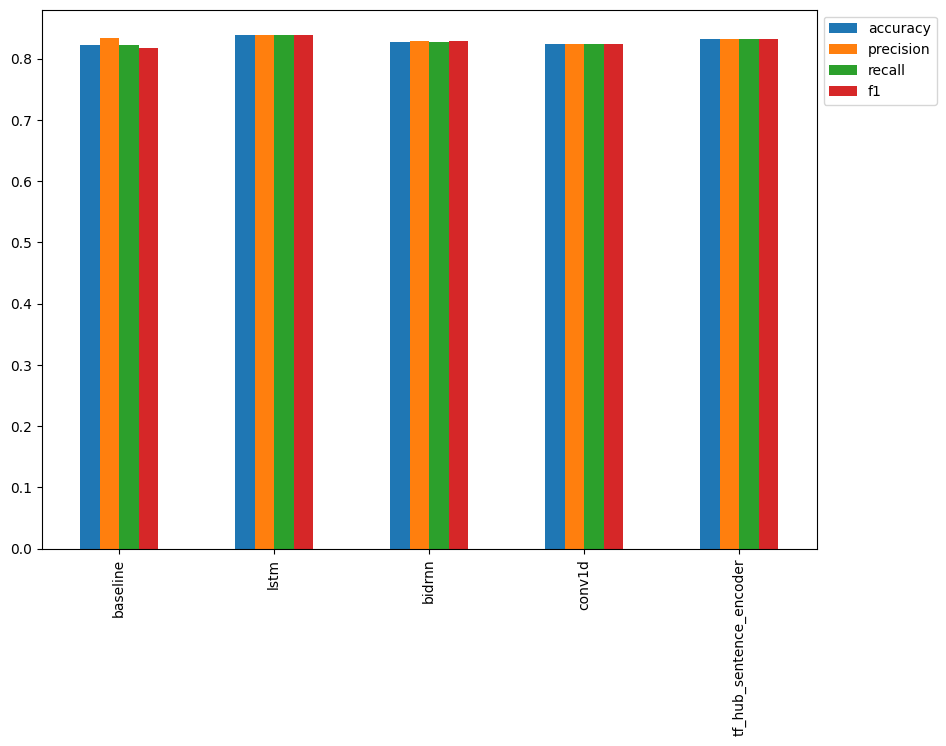

In [68]:
model_results["accuracy"] = model_results["accuracy"]/100
model_results.plot(kind="bar", figsize=(10, 7)).legend(bbox_to_anchor=(1.0, 1.0));

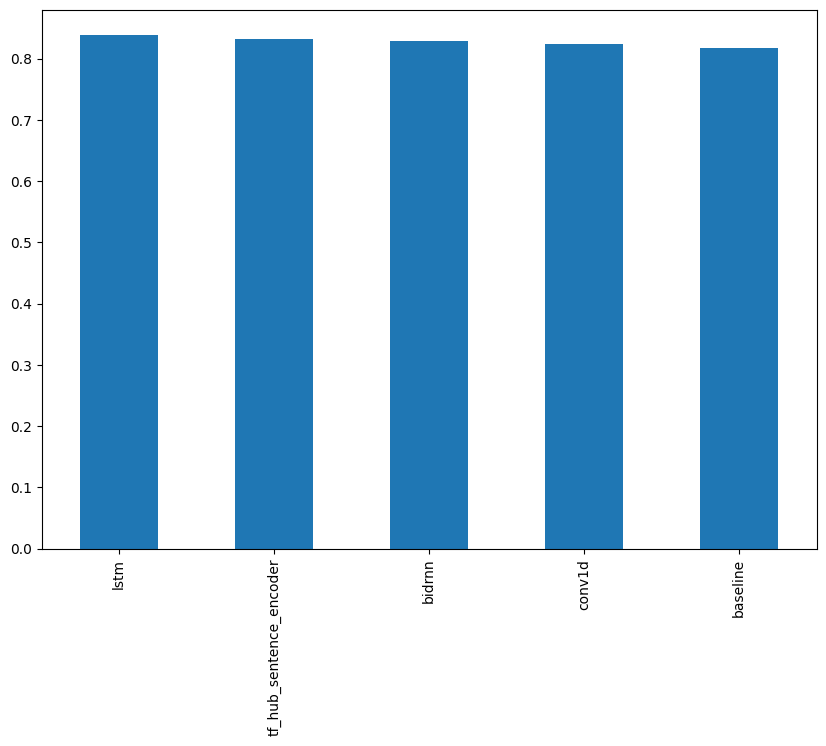

In [69]:
model_results.sort_values("f1", ascending=False)["f1"].plot(kind="bar", figsize=(10, 7));

In [70]:
#save the best one

In [72]:
model_1.save("model_1.keras")

In [73]:
model_4.save("model_4.keras")

In [74]:
#load the model

In [78]:
load_model_4 = tf.keras.models.load_model("model_4.keras", custom_objects={"KerasLayer": hub.KerasLayer})

In [80]:
model_1_pretrained = tf.keras.models.load_model("model_1.keras")

In [81]:
model_1_pretrained.evaluate(X_test, y_test)

167/167 [==============================] - 6s 8ms/step - loss: 0.9046 - accuracy: 0.8278


[0.9046003222465515, 0.8277798295021057]

In [82]:
#predictions

In [87]:
test_sentences = [
    "Yeah right!, like that's going to work",
    "The movie was not good",
    "It’s okay if you don’t like me. Not everyone has good taste."
]

for sentence in test_sentences:
  pred_prob = model_1_pretrained.predict([sentence])
  pred = tf.squeeze(tf.round(pred_prob))
  print(f"pred: {int(pred)}, pred_prob: {pred_prob}, pred_class: {int(pred)}")

1/1 [==============================] - 0s 53ms/step
pred: 1, pred_prob: [[0.99993706]], pred_class: 1
1/1 [==============================] - 0s 60ms/step
pred: 0, pred_prob: [[0.00805898]], pred_class: 0
1/1 [==============================] - 0s 62ms/step
pred: 1, pred_prob: [[0.99999297]], pred_class: 1
